In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import math

class Transpose(nn.Module):
    def __init__(self, dim0, dim1):
        super().__init__()
        self.dim0 = dim0
        self.dim1 = dim1

    def forward(self, x):
        return x.transpose(self.dim0, self.dim1)

class PositionalEncoding2D(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.register_buffer('pos_embed', self.build_sincos_encoding(num_patches, dim), persistent=False)

    def build_sincos_encoding(self, num_patches, dim):
        pe = torch.zeros(num_patches, dim)
        position = torch.arange(0, num_patches, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  # [1, num_patches, dim]

    def forward(self, x):
        return x + self.pos_embed[:, :x.size(1), :]

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels)
        )
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)

class CondEncoder(nn.Module):
    def __init__(self, in_channels=4, out_channels=768, num_tokens=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock(in_channels, 64),# [B, 64, 128, 128]
            nn.AvgPool2d(2),# [B, 64, 64, 64]
            ResidualBlock(64, 128),
            nn.AvgPool2d(2),# [B, 128, 32, 32]
            ResidualBlock(128, 256),
            nn.AvgPool2d(2),# [B, 256, 16, 16]
            ResidualBlock(256, 512),
            nn.AvgPool2d(2),# [B, 512, 8, 8]
            nn.Conv2d(512, out_channels, kernel_size=1)  # [B, 736, 8, 8]
        )
        self.proj = nn.Sequential(
            nn.Flatten(2),        # [B, 736, 64]
            Transpose(-1, -2),    # [B, 64, 736]
        )
        self.pos_embed = PositionalEncoding2D(num_patches=num_tokens, dim=out_channels)
        self.norm = nn.LayerNorm(out_channels)

    def forward(self, x):
        feat = self.encoder(x)          # [B, 736, 8, 8]
        tokens = self.proj(feat)        # [B, 64, 736]
        tokens = self.pos_embed(tokens) # [B, 64, 736]
        tokens = self.norm(tokens)
        return tokens


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMScheduler, UNet2DConditionModel, AutoencoderKL
from accelerate import Accelerator
import os
from PIL import Image
from torchvision import transforms
import numpy as np
from tqdm.auto import tqdm
import random
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF

class OutpaintDataset(Dataset):
    def __init__(self, root_dir, img_size=1024, masks_per_image=50):
        self.img_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir)]
        self.img_size = img_size
        self.masks_per_image = masks_per_image
        self.transform = transforms.Compose([
            transforms.RandomChoice([
                  transforms.Lambda(lambda x: x),
                  transforms.Lambda(lambda x: TF.rotate(x, 90)),
                  transforms.Lambda(lambda x: TF.rotate(x, 180)),
                  transforms.Lambda(lambda x: TF.rotate(x, 270))
            ]),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
        self.aug = transforms.Compose([
            transforms.RandomApply([transforms.ColorJitter(0.3, 0.3, 0.3, 0.1)], p=0.8),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.5)
        ])

    def __len__(self):
        return len(self.img_files) * self.masks_per_image

    def _gen_random_bbox(self):
      """Generate biased random bounding boxes with extreme or moderate aspect ratios."""
      mode = random.random()
      if mode < 0.5:
        if random.random() < 0.5:
            aspect_ratio = random.uniform(10.0, 33.0)  # very wide
        else:
            aspect_ratio = random.uniform(0.03, 0.1)   # very tall
      else:
        if random.random() < 0.5:
          aspect_ratio = random.uniform(0.1, 1.0)
        else:
          aspect_ratio = random.uniform(1.0, 10.0)

      area = random.uniform(0.1, 0.4)**2
      w = min(np.sqrt(area * aspect_ratio), 1)
      h = min(np.sqrt(area / aspect_ratio), 1)
      x1 = random.uniform(0, 1 - w)
      y1 = random.uniform(0, 1 - h)
      return (torch.tensor(x1, dtype=torch.float16),
            torch.tensor(y1, dtype=torch.float16),
            torch.tensor(x1 + w, dtype=torch.float16),
            torch.tensor(y1 + h, dtype=torch.float16))

    def _check_mask_validity(self, img, mask):
      """
      Check if more than 80% of the masked region in the img is pure white.
      img: normalized tensor after transform (shape [3, H, W])
      mask: tensor of 0 and 1 (same shape as img)
      """
      # First, get the masked area
      selected_pixels = img[:, mask[0] == 1]

      # Check where all channels == 1.0 (pure white)
      white_pixels = (selected_pixels == 1.0).all(dim=0)  # [N]

      # Calculate ratio of white pixels in the masked region
      white_ratio = white_pixels.float().mean()

      return white_ratio < 0.95


    def __getitem__(self, idx):
        img_idx = idx // self.masks_per_image
        img = Image.open(self.img_files[img_idx]).convert("RGB")
        img = self.transform(img)

        # Generate a random mask and apply it
        bbox = self._gen_random_bbox()
        mask = torch.zeros_like(img)
        h, w = img.shape[1], img.shape[2]
        x1 = int(bbox[0] * w)
        y1 = int(bbox[1] * h)
        x2 = int(bbox[2] * w)
        y2 = int(bbox[3] * h)
        mask[:, x1:x2, y1:y2] = 1

        if not self._check_mask_validity(img, mask):
            return self.__getitem__(idx)

        # Apply mask and augmentation
        masked_img = img * (1 - mask)

        #masked_img = self.aug(masked_img)

        #if random.random() < 0.8:
        #    noise = torch.randn_like(masked_img) * random.uniform(0.03, 0.15)
        #    masked_img = torch.clamp(masked_img + noise, -1, 1)

        return masked_img, img, torch.tensor(bbox)

class OutpaintTrainer_new:
    def __init__(self, pretrained_path="runwayml/stable-diffusion-v1-5"):
        # Initialize Accelerator for FP16 mixed precision
        self.accelerator = Accelerator(mixed_precision='fp16')
        self.loss_history = []
        self.val_loss_history = []

        # Dataset and DataLoader
        train_data = OutpaintDataset("drive/MyDrive/resize")#, masks_per_image=60)
        val_data = OutpaintDataset("drive/MyDrive/resizeval")#, masks_per_image=40)
        self.train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
        self.val_loader = DataLoader(val_data, batch_size=4, shuffle=False)

        # Load model components
        self.vae = AutoencoderKL.from_pretrained(pretrained_path, subfolder="vae")
        self.unet = UNet2DConditionModel.from_pretrained(pretrained_path, subfolder="unet")

        # Conditional Projection Layer

        self.cond_proj = CondEncoder()

        # Prepare components for mixed precision
        components = [self.vae, self.unet, self.cond_proj, self.train_loader, self.val_loader]
        self.vae, self.unet, self.cond_proj, self.train_loader, self.val_loader = \
            self.accelerator.prepare(*components)

        # Optimizer
        self.optimizer = torch.optim.AdamW(
            list(self.unet.parameters()) +
            list(self.cond_proj.parameters()),
            lr = 5e-5)
        self.optimizer = self.accelerator.prepare(self.optimizer)

        # Noise Scheduler
        self.noise_scheduler = DDPMScheduler.from_pretrained(
            pretrained_path, subfolder="scheduler")

        # Freeze VAE
        self.vae.requires_grad_(False)
        self.accelerator.register_for_checkpointing(self.unet, self.cond_proj, self.optimizer)

    def _create_latent_mask(self, bbox, latent_shape):
        b, _, lh, lw = latent_shape
        masks = []
        for coords in bbox:
            x1 = coords[0] * lw
            y1 = coords[1] * lh
            x2 = coords[2] * lw
            y2 = coords[3] * lh

            xx, yy = torch.meshgrid(
                torch.arange(lw, device=self.accelerator.device),
                torch.arange(lh, device=self.accelerator.device))
            mask = ((xx >= x1) & (xx <= x2) & (yy >= y1) & (yy <= y2)).float()

            masks.append(mask)
        return torch.stack(masks).unsqueeze(1)

    def validate_step(self):
        self.unet.eval()
        self.training = False
        total_loss = 0.0
        num_batches = 0

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Validating"):
                loss = self.train_step(batch)
                total_loss += loss.item()
                num_batches += 1

        avg_val_loss = total_loss / num_batches
        print(f"Validation Loss: {avg_val_loss:.4f}")
        return avg_val_loss

    def train_step(self, batch):
        masked_imgs, target_imgs, bbox = batch

        # Encode target images to latent space
        with torch.no_grad():
            target_latents = self.vae.encode(target_imgs).latent_dist.sample()
            target_latents = target_latents * self.vae.config.scaling_factor

        latent_masks = self._create_latent_mask(bbox, target_latents.shape)

        # Noise addition
        noise = torch.randn_like(target_latents)
        timesteps = torch.randint(
            0, self.noise_scheduler.config.num_train_timesteps,
            (target_latents.shape[0],), device=target_latents.device)

        noisy_latents = self.noise_scheduler.add_noise(
            target_latents * latent_masks,  # Add noise only to the masked areas
            noise * latent_masks,
            timesteps
        )
        noisy_latents = target_latents * (1 - latent_masks) + noisy_latents

        with torch.no_grad():
            masked_latents = self.vae.encode(masked_imgs).latent_dist.sample()
            masked_latents = masked_latents * self.vae.config.scaling_factor

        condition = self.cond_proj(masked_latents)

        # Predict noise
        noise_pred = self.unet(noisy_latents, timesteps, encoder_hidden_states=condition).sample

        # Loss function
        loss = F.mse_loss(noise_pred * latent_masks, noise * latent_masks)

        return loss

    def train(self, epochs=300, patience=4):
        best_val_loss = 1
        patience_counter = 0

        for epoch in range(epochs):
            self.unet.train()
            progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch + 1} [Training]")
            epoch_losses = []

            for batch in progress_bar:
                with self.accelerator.accumulate():
                    loss = self.train_step(batch)
                    self.accelerator.backward(loss)

                    if self.accelerator.sync_gradients:
                        self.accelerator.clip_grad_norm_(self.unet.parameters(), 1.5)

                    self.optimizer.step()
                    self.optimizer.zero_grad()

                epoch_losses.append(loss.item())

            epoch_avg_loss = sum(epoch_losses) / len(epoch_losses)
            self.loss_history.append(epoch_avg_loss)

            val_loss = self.validate_step()
            self.val_loss_history.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                self.accelerator.wait_for_everyone()
                self.accelerator.save_state(f"drive/MyDrive/checkpoint_HR")
            else:
                patience_counter += 1
                print(f"Early Stopping Counter: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print("Early stopping triggered. Restoring best model and stopping training.")
                self.accelerator.wait_for_everyone()
                self.accelerator.save_state(f"drive/MyDrive/checkpoint_HighResolution_latest")
                break

            if epoch % 2 == 0 and epoch > 0:
              for param_group in self.optimizer.param_groups:
                param_group['lr'] *= 0.5
                print(f"Epoch {epoch}: lr = {param_group['lr']}")

            # Plot loss curves after each epoch
            self._plot_loss_curve()

    def _plot_loss_curve(self):
        """Plot both training and validation loss curves."""
        plt.figure(figsize=(8, 6))

        # Plot Training Loss
        plt.plot(range(1, len(self.loss_history) + 1), self.loss_history,
                label="Training Loss", marker='o', linestyle='-')

        # Plot Validation Loss
        plt.plot(range(1, len(self.val_loss_history) + 1), self.val_loss_history,
                label="Validation Loss", marker='s', linestyle='--', color='red')

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Curve")
        plt.legend()
        plt.grid(True)
        plt.show()
        plt.close()



In [ ]:
    torch.cuda.empty_cache()
    import gc
    gc.collect()

90

In [ ]:
#=======================================
# Training Execution
#=======================================
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
if __name__ == "__main__":
    torch.cuda.empty_cache()
    import gc
    gc.collect()
    #trainer.vae.decoder.load_state_dict(torch.load("drive/MyDrive/vae_training/decoder.pth"))
    trainer = OutpaintTrainer_new()
    accelerator = trainer.accelerator
    optimizer = torch.optim.AdamW([
            {"params": trainer.unet.parameters(), "lr": 1e-5},
            {"params": trainer.cond_proj.parameters(), "lr": 1e-4},
          ])
    trainer.optimizer = trainer.accelerator.prepare(optimizer)

Epoch 1 [Training]:   0%|          | 0/800 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Validating:   0%|          | 0/63 [00:00<?, ?it/s]

Validation Loss: 0.0109


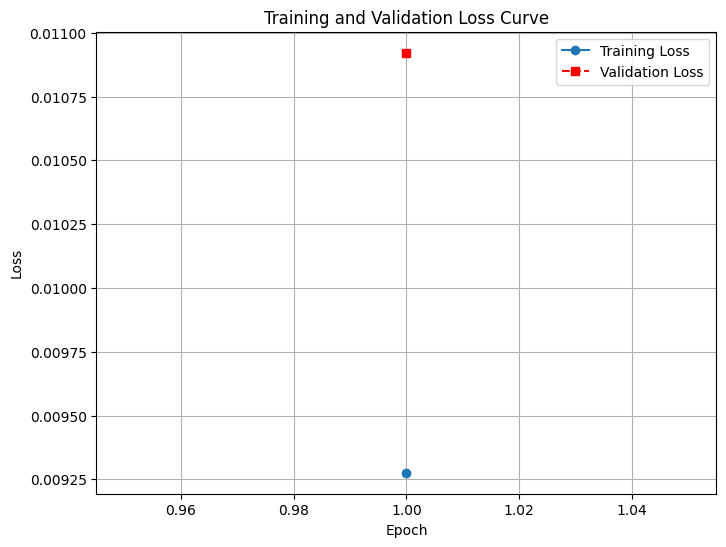

Epoch 2 [Training]:   0%|          | 0/800 [00:00<?, ?it/s]

In [ ]:
trainer.train(10)

In [ ]:
trainer.accelerator.wait_for_everyone()
trainer.accelerator.save_state(f"drive/MyDrive/checkpoint_HighResolution_latest")

PosixPath('drive/MyDrive/checkpoint_HighResolution_latest')

Epoch 1 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0362


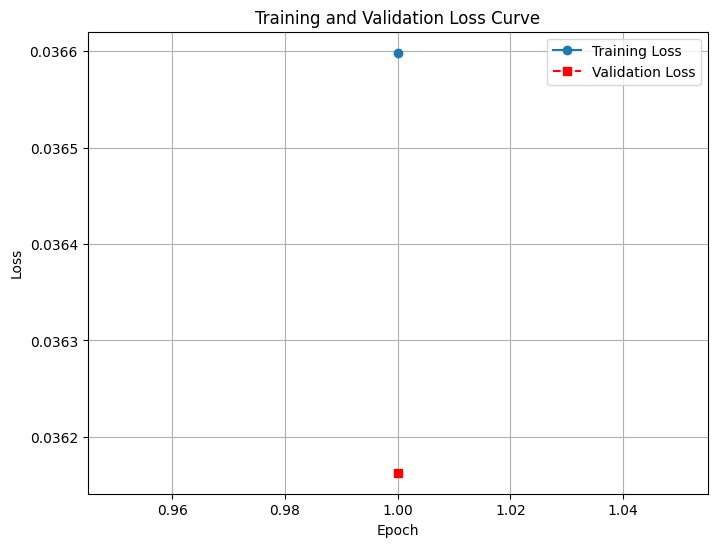

Epoch 2 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0358


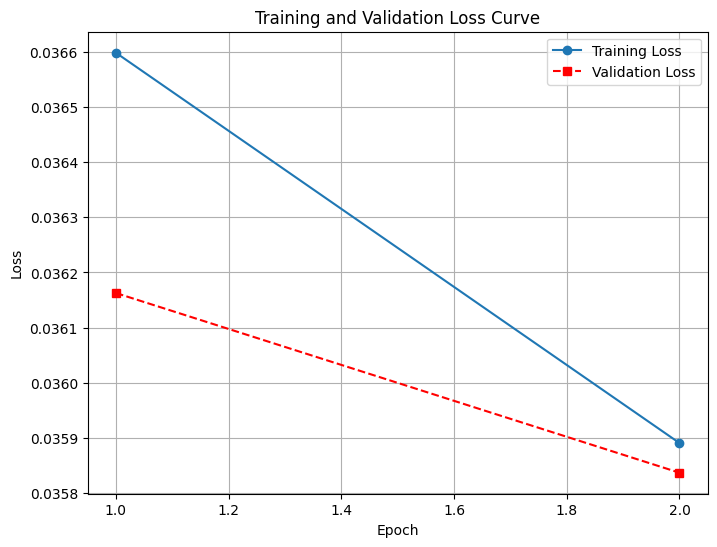

Epoch 3 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0365
Early Stopping Counter: 1/5


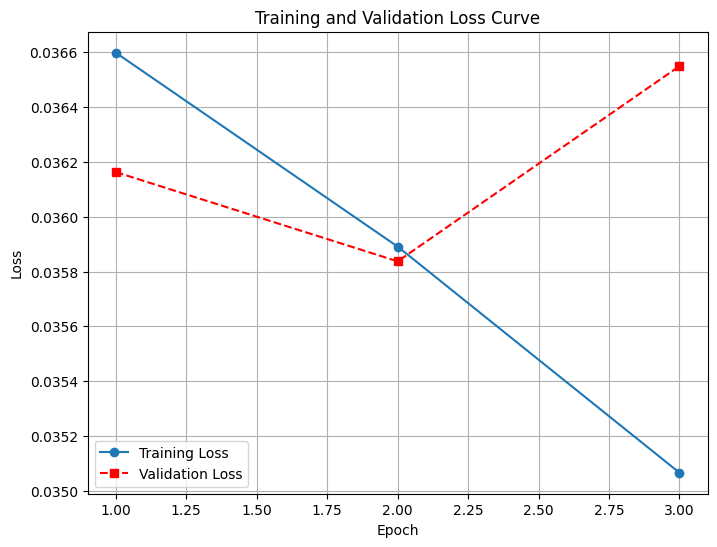

Epoch 4 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0365
Early Stopping Counter: 2/5
Epoch 3: lr = 3e-05


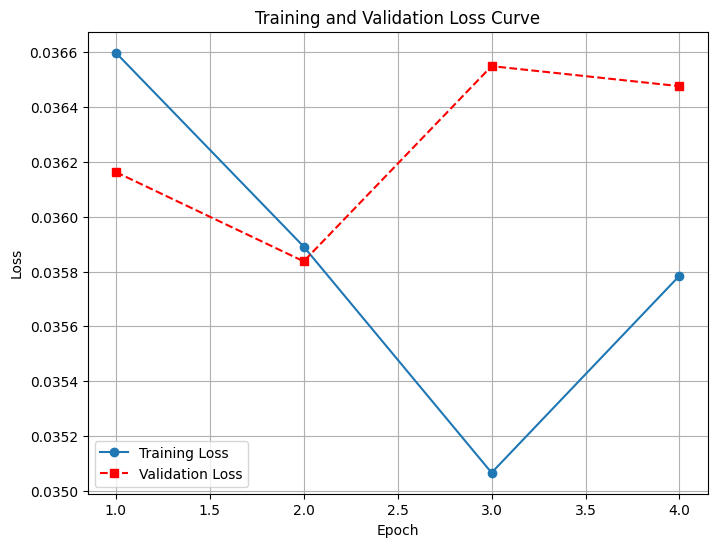

Epoch 5 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0330


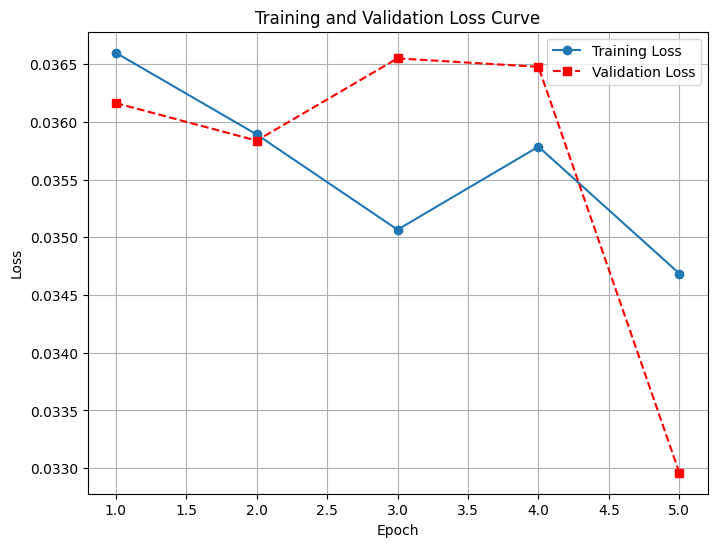

Epoch 6 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0322


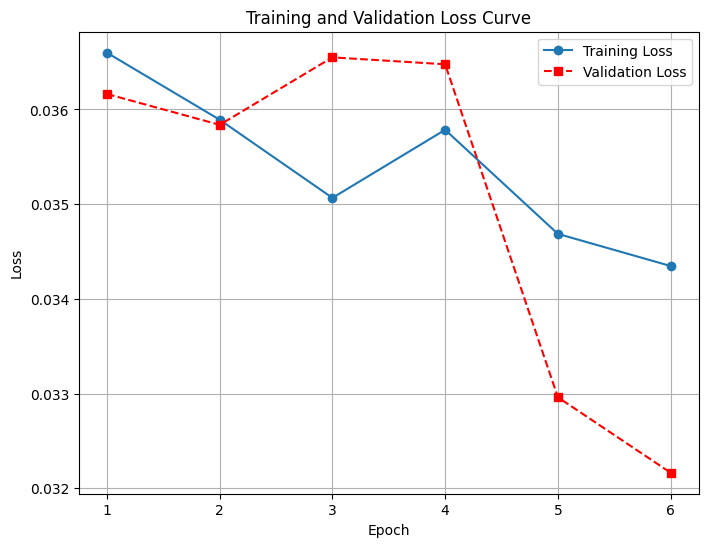

Epoch 7 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0336
Early Stopping Counter: 1/5
Epoch 6: lr = 1.5e-05


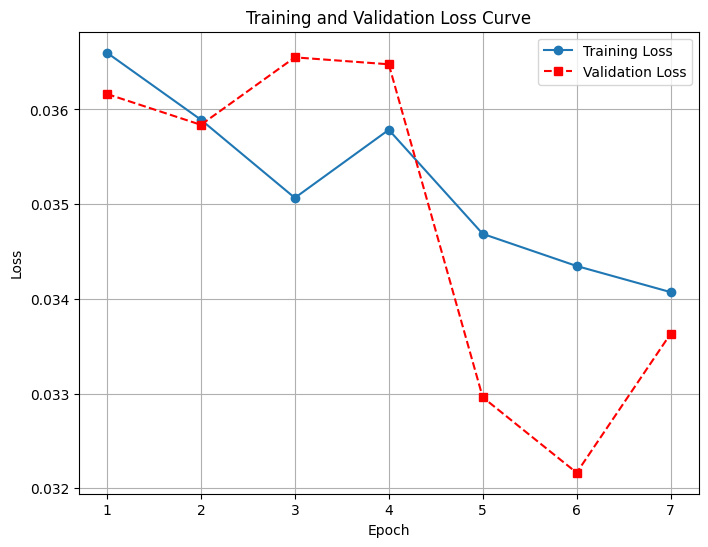

Epoch 8 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

Validating:   0%|          | 0/43 [00:00<?, ?it/s]

Validation Loss: 0.0325
Early Stopping Counter: 2/5


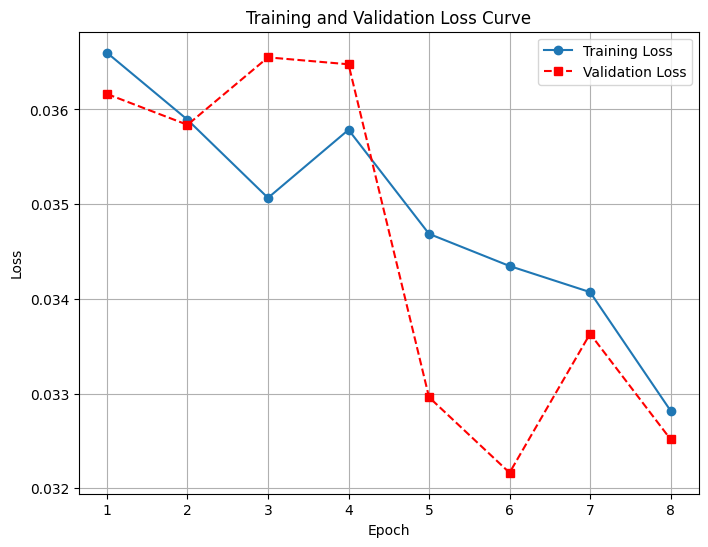

Epoch 9 [Training]:   0%|          | 0/653 [00:00<?, ?it/s]

In [ ]:
trainer.train(10)